<a href="https://colab.research.google.com/github/Gerardortizle/analisis-sentimiento-farmacias/blob/main/Act_4_Comparacion_Modelos_HF_JGOL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 4 · Selección e implementación de modelos preentrenados (Hugging Face + Colab)
**Gestión de proyectos de inteligencia artificial** — Universidad Tecmilenio
**Alumno:** José Gerardo Ortiz Leñero  ·  **Profesora:** Ing. Tania Judith Mendoza Torres

**Rama de IA:** Procesamiento de Lenguaje Natural (NLP) · **Tarea:** clasificación de sentimiento en español (3 clases: NEG / NEU / POS)

**Caso de uso:** *Farmacias Occidente Salud* (cadena ficticia, 140 sucursales en el occidente de México) quiere clasificar automáticamente las reseñas de clientes (Google Reviews, Facebook y encuestas internas) para detectar a tiempo quejas por surtido, atención y tiempos de espera.

**Modelos comparados (Hugging Face Hub):**
| # | Modelo | Arquitectura | Salida original |
|---|---|---|---|
| M1 | `pysentimiento/robertuito-sentiment-analysis` | RoBERTa (español, redes sociales) | POS / NEU / NEG |
| M2 | `cardiffnlp/twitter-xlm-roberta-base-sentiment` | XLM-RoBERTa base (multilingüe) | positive / neutral / negative |
| M3 | `nlptown/bert-base-multilingual-uncased-sentiment` | BERT base multilingüe | 1–5 estrellas |
| M4 | `lxyuan/distilbert-base-multilingual-cased-sentiments-student` | DistilBERT multilingüe (destilado) | positive / neutral / negative |

**Orden de ejecución:** Entorno de ejecución → Cambiar tipo → **GPU T4** → ejecutar las celdas en orden. Después de la celda 2 **reinicia la sesión** (obligatorio) y continúa desde la celda 3.

## Celda 1 · Configuración y verificación de la GPU

In [1]:
!nvidia-smi
import torch
print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ No hay GPU. Activa: Entorno de ejecución > Cambiar tipo de entorno > GPU T4")

Fri Oct  9 16:06:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Celda 2 · Instalación de dependencias
Se instalan explícitamente las librerías del flujo de T10. Al terminar, **reinicia la sesión** (Entorno de ejecución → Reiniciar sesión) para que las nuevas versiones se carguen en memoria.

In [2]:
!pip install -q "transformers>=4.44" "datasets>=2.20" "evaluate>=0.4.2" "accelerate>=0.33" \
    "huggingface_hub>=0.24" sentencepiece scikit-learn python-docx
import importlib
for pkg in ["transformers", "datasets", "evaluate", "accelerate", "huggingface_hub", "sklearn", "torch", "pandas"]:
    try:
        print(f"{pkg:16s}", importlib.import_module(pkg).__version__)
    except Exception as e:
        print(f"{pkg:16s} no disponible: {e}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 12.2 MB/s eta 0:00:00
transformers     5.18.0
datasets         4.8.5
evaluate         0.4.6
accelerate       1.15.0
huggingface_hub  1.33.0
sklearn          1.6.1
torch            2.11.0+cu130
pandas           2.2.3


## Celda 3 · Autenticación en Hugging Face Hub
Opción recomendada: guardar el token en **Secrets** de Colab (ícono 🔑) con el nombre `HF_TOKEN` y permiso *Read*. Si no existe, se solicita de forma interactiva con `login()`. El token nunca queda escrito en el código.

In [3]:
import os
from huggingface_hub import login, whoami
try:
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
    print("Token cargado desde Colab Secrets.")
except Exception:
    print("No se encontró HF_TOKEN en Secrets; se solicitará el token.")
    login()
try:
    print("Autenticado como:", whoami()["name"])
except Exception as e:
        raise RuntimeError(f"Token de Hugging Face inválido: {e}. Genera uno nuevo (Read) y actualiza HF_TOKEN en Secrets.")

Token cargado desde Colab Secrets.
Autenticado como: Gerardorle


## Celda 4 · Configuración del proyecto y obtención del repositorio
Se fijan semillas para reproducibilidad y se clona el repositorio (contiene `data/`, `src/` y `docs/`). Si prefieres no clonarlo, deja `REPO_URL = ""` y sube el CSV cuando se te pida.

In [4]:
import random, numpy as np, torch, os, subprocess
from pathlib import Path

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

REPO_URL = "https://github.com/gerardortizle/analisis-sentimiento-farmacias.git"   # <-- edita
REPO_DIR = Path("/content/analisis-sentimiento-farmacias")


if REPO_URL and not REPO_DIR.exists():
    subprocess.run(["git", "clone", "-q", REPO_URL, str(REPO_DIR)], check=False)

if REPO_DIR.exists():
    os.chdir(REPO_DIR)
else:
    REPO_DIR = Path("/content"); os.chdir(REPO_DIR)
    Path("data").mkdir(exist_ok=True)

DATA_PATH = Path("data/resenas_farmacias.csv")
RESULTS = Path("results"); RESULTS.mkdir(exist_ok=True)

if not DATA_PATH.exists():
    if Path("src/generar_dataset.py").exists():
        subprocess.run(["python", "src/generar_dataset.py"], check=True)   # regenera con semilla 42
    else:
        from google.colab import files
        print("Sube data/resenas_farmacias.csv"); up = files.upload()
        DATA_PATH.write_bytes(next(iter(up.values())))
print("Directorio de trabajo:", Path.cwd(), "| Dataset:", DATA_PATH.resolve())

Directorio de trabajo: /content/analisis-sentimiento-farmacias | Dataset: /content/analisis-sentimiento-farmacias/data/resenas_farmacias.csv


## Celda 5 · Carga del dataset (pandas + 🤗 Datasets) y análisis exploratorio

In [5]:
import pandas as pd
from datasets import Dataset

df = pd.read_csv(DATA_PATH)
print(df.shape); display(df.head())

ds = Dataset.from_pandas(df)          # mismo dataset en formato Hugging Face Datasets
print(ds)

dist = (df["sentimiento"].value_counts().rename("registros").to_frame()
        .assign(porcentaje=lambda d: (100 * d.registros / d.registros.sum()).round(1)))
display(dist)
print("Relación clase mayoritaria / minoritaria:", round(dist.registros.max() / dist.registros.min(), 2))
display(pd.crosstab(df["categoria"], df["sentimiento"]))
print(df["dificultad"].value_counts())
# (Opcional) publicar el dataset en el Hub:  ds.push_to_hub("<tu-usuario>/resenas-farmacias-sinteticas", private=True)

(300, 9)


,id_resena,fecha,sucursal,ciudad,canal,categoria,texto,sentimiento,dificultad
0,R0001,2026-08-23,FOS-COL-052,Colima,Encuesta interna,atencion,"Muy buen trato, la cajera me ayudó a encontrar...",positivo,normal
1,R0002,2026-04-03,FOS-GDL-014,Guadalajara,Facebook,atencion,"La cajera me atendió, sin más. Ni bien ni mal.",neutral,normal
2,R0003,2026-05-16,FOS-GDL-014,Guadalajara,Facebook,surtido,No tenían el medicamento para la presión y no ...,negativo,normal
3,R0004,2026-02-05,FOS-TEP-063,Tepic,Google Reviews,atencion,"Excelente atención de el chico del mostrador, ...",positivo,normal
4,R0005,2026-04-30,FOS-TLQ-031,Tlaquepaque,Facebook,surtido,Tenían el medicamento para la presión pero sol...,neutral,normal


Dataset({
    features: ['id_resena', 'fecha', 'sucursal', 'ciudad', 'canal', 'categoria', 'texto', 'sentimiento', 'dificultad'],
    num_rows: 300
})


,registros,porcentaje
sentimiento,,
positivo,160,53.3
neutral,76,25.3
negativo,64,21.3


Relación clase mayoritaria / minoritaria: 2.5


sentimiento,negativo,neutral,positivo
categoria,,,
atencion,12,32,85
instalaciones,2,6,2
precio,12,15,22
surtido,22,19,20
tiempo_espera,16,4,31


dificultad
normal     264
dificil     36
Name: count, dtype: int64


## Celda 6 · Ajustes mínimos de entrada (limpieza y normalización de etiquetas)
- Limpieza ligera del texto (espacios repetidos, vacíos). No se eliminan emojis ni signos: los modelos de redes sociales los aprovechan.
- Mapeo de etiquetas reales `positivo / neutral / negativo` → `POS / NEU / NEG` y a enteros (`NEG=0, NEU=1, POS=2`) para `evaluate`.

In [6]:
import re
MAPA_REAL = {"positivo": "POS", "neutral": "NEU", "negativo": "NEG"}
CLASES = ["NEG", "NEU", "POS"]
A_ID = {c: i for i, c in enumerate(CLASES)}

df["texto"] = df["texto"].astype(str).str.strip().apply(lambda t: re.sub(r"\s+", " ", t))
df = df[df["texto"].str.len() > 0].reset_index(drop=True)
df["y_true"] = df["sentimiento"].str.lower().map(MAPA_REAL)
assert df["y_true"].notna().all(), "Hay etiquetas sin mapear"
textos = df["texto"].tolist()
y_true = df["y_true"].tolist()
print(df["y_true"].value_counts())

y_true
POS    160
NEU     76
NEG     64
Name: count, dtype: int64


## Celda 7 · Modelos a comparar y metadatos del Hub
Se consultan en el Hub la licencia declarada, descargas y tamaño de pesos de cada modelo (criterios prácticos de selección).

In [7]:
from huggingface_hub import HfApi
MODELOS = {
    "M1_RoBERTuito":  "pysentimiento/robertuito-sentiment-analysis",
    "M2_XLM-R_Twitter": "cardiffnlp/twitter-xlm-roberta-base-sentiment",
    "M3_BERT_mult_5estrellas": "nlptown/bert-base-multilingual-uncased-sentiment",
    "M4_DistilBERT_mult": "lxyuan/distilbert-base-multilingual-cased-sentiments-student",
}
api = HfApi()
meta = {}
for alias, mid in MODELOS.items():
    try:
        info = api.model_info(mid, files_metadata=True)
        lic = (info.card_data or {}).get("license") if info.card_data else None
        lic = lic or next((t.split(":", 1)[1] for t in (info.tags or []) if t.startswith("license:")), "no declarada")
        pesos = [s.size or 0 for s in info.siblings if s.rfilename.endswith(".safetensors")] or \
                [s.size or 0 for s in info.siblings if s.rfilename.endswith(".bin")]
        meta[alias] = {"modelo": mid, "tarea": info.pipeline_tag, "licencia": lic,
                       "descargas_mes": info.downloads, "disco_MB": round(sum(pesos) / 1e6, 1)}
    except Exception as e:
        meta[alias] = {"modelo": mid, "tarea": "text-classification", "licencia": "verificar",
                       "descargas_mes": None, "disco_MB": None}
        print(alias, "metadatos no disponibles:", e)
df_meta = pd.DataFrame(meta).T
display(df_meta)

,modelo,tarea,licencia,descargas_mes,disco_MB
M1_RoBERTuito,pysentimiento/robertuito-sentiment-analysis,text-classification,no declarada,468093,435.2
M2_XLM-R_Twitter,cardiffnlp/twitter-xlm-roberta-base-sentiment,text-classification,no declarada,682774,1112.3
M3_BERT_mult_5estrellas,nlptown/bert-base-multilingual-uncased-sentiment,text-classification,mit,689904,669.5
M4_DistilBERT_mult,lxyuan/distilbert-base-multilingual-cased-sent...,text-classification,apache-2.0,597721,541.3


## Celda 8 · Funciones de inferencia, normalización de salidas y medición de latencia
**Ajuste mínimo de salidas:** cada modelo usa un esquema distinto (`POS`, `positive`, `LABEL_2`, `4 stars`). Se normalizan a `NEG / NEU / POS`; en el modelo de estrellas: 1–2 = NEG, 3 = NEU, 4–5 = POS.

**Latencia:** se reportan (a) tiempo medio por reseña en lote (`batch_size=16`, *throughput*) y (b) latencia individual p50/p95 sobre 50 reseñas (escenario en línea), tras un calentamiento.

In [8]:
import time, gc
import evaluate
from transformers import pipeline
from sklearn.metrics import classification_report, confusion_matrix

DEVICE = 0 if torch.cuda.is_available() else -1
BATCH = 16
TOK_KW = dict(truncation=True, max_length=128)   # RoBERTuito admite máx. 128 tokens

m_acc = evaluate.load("accuracy"); m_prec = evaluate.load("precision")
m_rec = evaluate.load("recall");   m_f1 = evaluate.load("f1")

def normalizar_prediccion(label: str) -> str:
    l = str(label).strip().lower()
    if "star" in l:
        n = int(l[0]); return "NEG" if n <= 2 else ("NEU" if n == 3 else "POS")
    if l.startswith("pos"): return "POS"
    if l.startswith("neg"): return "NEG"
    if l.startswith("neu"): return "NEU"
    return {"label_0": "NEG", "label_1": "NEU", "label_2": "POS"}.get(l, "NEU")

def sync():
    if torch.cuda.is_available(): torch.cuda.synchronize()

def evaluar_modelo(alias, model_id):
    if torch.cuda.is_available():
        torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    t0 = time.perf_counter()
    clf = pipeline("text-classification", model=model_id, tokenizer=model_id, device=DEVICE)
    t_carga = time.perf_counter() - t0
    n_params = clf.model.num_parameters()

    clf(textos[:8], batch_size=8, **TOK_KW); sync()           # calentamiento
    t0 = time.perf_counter()
    salida = clf(textos, batch_size=BATCH, **TOK_KW); sync()
    t_total = time.perf_counter() - t0

    lat = []
    for t in textos[:50]:
        sync(); a = time.perf_counter(); clf(t, **TOK_KW); sync(); lat.append((time.perf_counter() - a) * 1000)

    y_pred = [normalizar_prediccion(o["label"]) for o in salida]
    yt = [A_ID[c] for c in y_true]; yp = [A_ID[c] for c in y_pred]
    rep = classification_report(y_true, y_pred, labels=CLASES, output_dict=True, zero_division=0)
    res = {
        "alias": alias, "modelo": model_id,
        "accuracy": m_acc.compute(predictions=yp, references=yt)["accuracy"],
        "precision_macro": m_prec.compute(predictions=yp, references=yt, average="macro", zero_division=0)["precision"],
        "recall_macro": m_rec.compute(predictions=yp, references=yt, average="macro", zero_division=0)["recall"],
        "f1_macro": m_f1.compute(predictions=yp, references=yt, average="macro")["f1"],
        "f1_weighted": m_f1.compute(predictions=yp, references=yt, average="weighted")["f1"],
        "recall_NEG": rep["NEG"]["recall"], "recall_NEU": rep["NEU"]["recall"], "recall_POS": rep["POS"]["recall"],
        "lat_lote_ms": 1000 * t_total / len(textos),
        "lat_p50_ms": float(np.percentile(lat, 50)), "lat_p95_ms": float(np.percentile(lat, 95)),
        "throughput_rps": len(textos) / t_total,
        "t_carga_s": t_carga, "params_M": n_params / 1e6,
        "vram_pico_MB": torch.cuda.max_memory_allocated() / 1e6 if torch.cuda.is_available() else None,
    }
    del clf; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return res, y_pred

## Celda 9 · Pipeline de inferencia sobre el dataset completo (4 modelos)
Inferencia *zero-shot* (sin reentrenar): los 300 registros funcionan como conjunto de prueba.

In [9]:
resultados, predicciones = [], {}
for alias, mid in MODELOS.items():
    print(f"▶ {alias}: {mid}")
    try:
        r, yp = evaluar_modelo(alias, mid)
        resultados.append(r); predicciones[alias] = yp
        print(f"   accuracy={r['accuracy']:.3f}  F1-macro={r['f1_macro']:.3f}  "
              f"lat/reseña(lote)={r['lat_lote_ms']:.2f} ms  p95={r['lat_p95_ms']:.1f} ms")
    except Exception as e:
        print(f"   ✖ Error con {alias}: {e}")
df_res = pd.DataFrame(resultados).set_index("alias")

▶ M1_RoBERTuito: pysentimiento/robertuito-sentiment-analysis


config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  435MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.92M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

   accuracy=0.610  F1-macro=0.486  lat/reseña(lote)=2.35 ms  p95=26.4 ms


## Celda 10 · Tabla de métricas de calidad y matrices de confusión

,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,recall_NEG,recall_NEU,recall_POS
alias,,,,,,,,
M1_RoBERTuito,0.800000,0.785000,0.829000,0.797000,0.804000,0.953000,0.789000,0.744000
M2_XLM-R_Twitter,0.820000,0.803000,0.842000,0.817000,0.822000,0.922000,0.829000,0.775000
M3_BERT_mult_5estrellas,0.697000,0.620000,0.641000,0.597000,0.674000,0.844000,0.211000,0.869000
M4_DistilBERT_mult,0.610000,0.513000,0.513000,0.486000,0.587000,0.531000,0.145000,0.862000


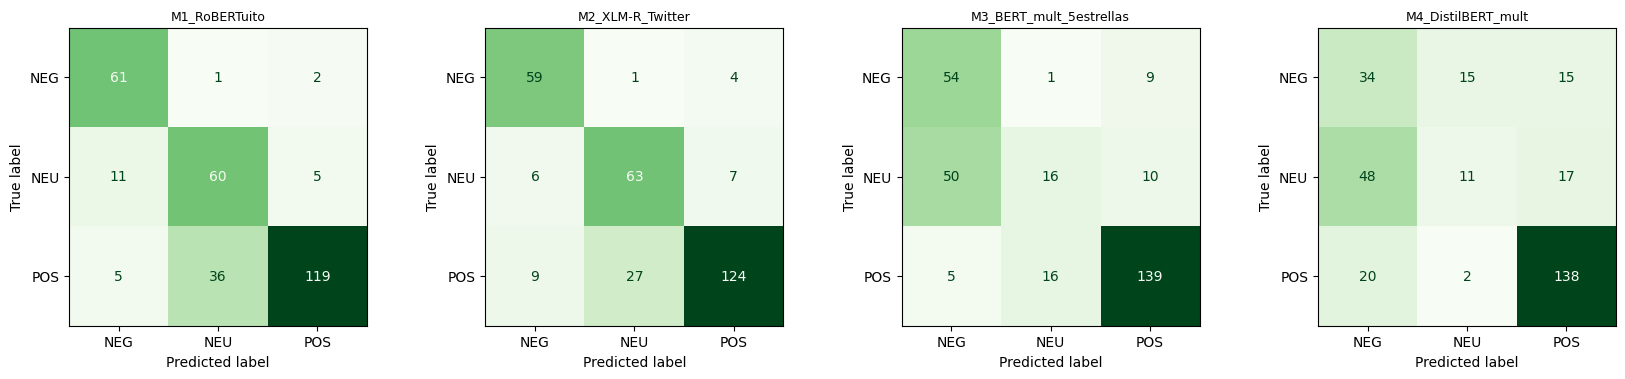


=== M1_RoBERTuito ===
              precision    recall  f1-score   support

         NEG      0.792     0.953     0.865        64
         NEU      0.619     0.789     0.694        76
         POS      0.944     0.744     0.832       160

    accuracy                          0.800       300
   macro avg      0.785     0.829     0.797       300
weighted avg      0.829     0.800     0.804       300


=== M2_XLM-R_Twitter ===
              precision    recall  f1-score   support

         NEG      0.797     0.922     0.855        64
         NEU      0.692     0.829     0.754        76
         POS      0.919     0.775     0.841       160

    accuracy                          0.820       300
   macro avg      0.803     0.842     0.817       300
weighted avg      0.835     0.820     0.822       300


=== M3_BERT_mult_5estrellas ===
              precision    recall  f1-score   support

         NEG      0.495     0.844     0.624        64
         NEU      0.485     0.211     0.294    

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cols_cal = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_weighted", "recall_NEG", "recall_NEU", "recall_POS"]
display(df_res[cols_cal].round(3).style.highlight_max(axis=0, color="#c6efce"))

fig, axes = plt.subplots(1, len(predicciones), figsize=(4.2 * len(predicciones), 3.8))
axes = np.atleast_1d(axes)
for ax, (alias, yp) in zip(axes, predicciones.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_true, yp, labels=CLASES), display_labels=CLASES).plot(
        ax=ax, colorbar=False, cmap="Greens")
    ax.set_title(alias, fontsize=9)
plt.tight_layout(); plt.savefig(RESULTS / "matrices_confusion.png", dpi=150); plt.show()

for alias, yp in predicciones.items():
    print(f"\n=== {alias} ===")
    print(classification_report(y_true, yp, labels=CLASES, digits=3, zero_division=0))

## Celda 11 · Eficiencia: latencia, throughput y recursos

,params_M,vram_pico_MB,t_carga_s,lat_lote_ms,lat_p50_ms,lat_p95_ms,throughput_rps,licencia,disco_MB
alias,,,,,,,,,
M1_RoBERTuito,108.79,461.11,9.36,1.61,9.04,11.56,622.27,no declarada,435.2
M2_XLM-R_Twitter,278.05,1139.81,18.24,4.01,24.59,67.44,249.61,no declarada,1112.3
M3_BERT_mult_5estrellas,167.36,697.32,7.67,1.86,8.88,10.01,536.46,mit,669.5
M4_DistilBERT_mult,135.33,569.92,10.57,2.35,19.31,26.45,425.78,apache-2.0,541.3


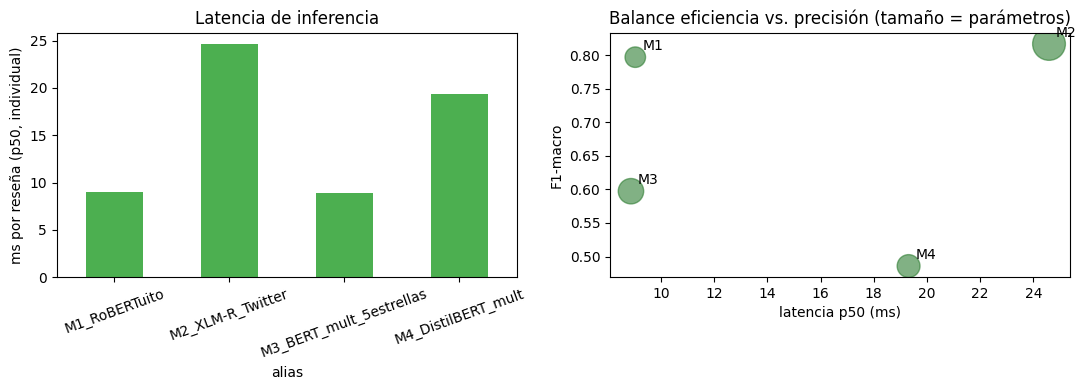

In [11]:
cols_ef = ["params_M", "vram_pico_MB", "t_carga_s", "lat_lote_ms", "lat_p50_ms", "lat_p95_ms", "throughput_rps"]
tabla_ef = df_res[cols_ef].join(df_meta[["licencia", "disco_MB"]])
display(tabla_ef.round(2))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df_res["lat_p50_ms"].plot.bar(ax=ax[0], color="#4caf50"); ax[0].set_ylabel("ms por reseña (p50, individual)")
ax[0].set_title("Latencia de inferencia"); ax[0].tick_params(axis="x", rotation=20)
ax[1].scatter(df_res["lat_p50_ms"], df_res["f1_macro"], s=df_res["params_M"] * 2, alpha=.6, color="#2e7d32")
for a, r in df_res.iterrows():
    ax[1].annotate(a.split("_")[0], (r.lat_p50_ms, r.f1_macro), xytext=(5, 5), textcoords="offset points")
ax[1].set_xlabel("latencia p50 (ms)"); ax[1].set_ylabel("F1-macro")
ax[1].set_title("Balance eficiencia vs. precisión (tamaño = parámetros)")
plt.tight_layout(); plt.savefig(RESULTS / "eficiencia_vs_precision.png", dpi=150); plt.show()

## Celda 12 · Análisis por subgrupos (casos difíciles y categoría)
Se verifica si el desempeño se sostiene en ironía, sentimiento mixto y negaciones (`dificultad = dificil`), que son los casos que más se ven en reseñas reales.

In [12]:
filas = []
for alias, yp in predicciones.items():
    tmp = df.assign(y_pred=yp, ok=lambda d: d.y_pred == d.y_true)
    fila = {"alias": alias}
    fila.update({f"acc_{k}": v for k, v in tmp.groupby("dificultad")["ok"].mean().items()})
    fila.update({f"acc_{k}": v for k, v in tmp.groupby("categoria")["ok"].mean().items()})
    filas.append(fila)
df_sub = pd.DataFrame(filas).set_index("alias")
display(df_sub.round(3))

,acc_dificil,acc_normal,acc_atencion,acc_instalaciones,acc_precio,acc_surtido,acc_tiempo_espera
alias,,,,,,,
M1_RoBERTuito,0.694,0.814,0.930,0.9,0.755,0.951,0.314
M2_XLM-R_Twitter,0.639,0.845,0.899,0.9,0.918,0.869,0.451
M3_BERT_mult_5estrellas,0.278,0.754,0.767,0.5,0.469,0.590,0.902
M4_DistilBERT_mult,0.278,0.655,0.690,0.4,0.653,0.393,0.667


## Celda 13 · Umbrales de negocio y regla de decisión
Umbrales definidos **antes** de ver resultados:
- `accuracy ≥ 0.80` (requisito de gerencia, igual que el caso de T10)
- `F1-macro ≥ 0.75` (el dataset está desbalanceado; la exactitud sola es engañosa)
- `recall NEG ≥ 0.75` (no perder quejas es el objetivo operativo)
- `latencia p95 ≤ 100 ms` por reseña en T4 (consulta en línea desde un tablero)

**Regla:** entre los modelos que cumplen todo, se elige el de mayor F1-macro; si dos quedan a ≤ 0.02 de F1, gana el más rápido. Si ninguno cumple, se recomienda el de mayor F1-macro y se activa el fine-tuning (celda 16).

In [13]:
UMBRALES = {"accuracy": 0.80, "f1_macro": 0.75, "recall_NEG": 0.75, "lat_p95_ms": 100.0}

def cumple(r):
    return (r.accuracy >= UMBRALES["accuracy"] and r.f1_macro >= UMBRALES["f1_macro"]
            and r.recall_NEG >= UMBRALES["recall_NEG"] and r.lat_p95_ms <= UMBRALES["lat_p95_ms"])

df_res["cumple_umbrales"] = df_res.apply(cumple, axis=1)
candidatos = df_res[df_res.cumple_umbrales]
if len(candidatos):
    mejor_f1 = candidatos.f1_macro.max()
    empatados = candidatos[candidatos.f1_macro >= mejor_f1 - 0.02]
    RECOMENDADO = empatados.lat_p50_ms.idxmin()
    REQUIERE_FT = False
else:
    RECOMENDADO = df_res.f1_macro.idxmax()
    REQUIERE_FT = True

MAS_PRECISO = df_res.f1_macro.idxmax()
MAS_RAPIDO = df_res.lat_p50_ms.idxmin()
display(df_res[["accuracy", "f1_macro", "recall_NEG", "lat_p95_ms", "cumple_umbrales"]].round(3))
print("Modelo recomendado:", RECOMENDADO, "| Requiere fine-tuning:", REQUIERE_FT)
print("Más preciso (F1):", MAS_PRECISO, "| Más rápido (p50):", MAS_RAPIDO)

,accuracy,f1_macro,recall_NEG,lat_p95_ms,cumple_umbrales
alias,,,,,
M1_RoBERTuito,0.800,0.797,0.953,11.561,True
M2_XLM-R_Twitter,0.820,0.817,0.922,67.440,True
M3_BERT_mult_5estrellas,0.697,0.597,0.844,10.010,False
M4_DistilBERT_mult,0.610,0.486,0.531,26.448,False


Modelo recomendado: M1_RoBERTuito | Requiere fine-tuning: False
Más preciso (F1): M2_XLM-R_Twitter | Más rápido (p50): M3_BERT_mult_5estrellas


## Celda 14 · Conclusiones parciales (generadas a partir de los resultados)

In [14]:
r = df_res
rp, rr = r.loc[MAS_PRECISO], r.loc[MAS_RAPIDO]
print(f"1) Calidad: {MAS_PRECISO} obtiene el mejor F1-macro ({rp.f1_macro:.3f}); "
      f"el peor es {r.f1_macro.idxmin()} ({r.f1_macro.min():.3f}).")
rec_cls = r[["recall_NEG", "recall_NEU", "recall_POS"]]
dificil = rec_cls.mean().idxmin().replace("recall_", "")
print(f"2) Por clase: la más difícil en promedio es {dificil} (recall medio {rec_cls.mean().min():.2f}); "
      f"el recall NEG va de {r.recall_NEG.min():.2f} a {r.recall_NEG.max():.2f} entre modelos.")
if MAS_PRECISO != MAS_RAPIDO:
    print(f"3) Trade-off: {MAS_RAPIDO} es {rp.lat_p50_ms / rr.lat_p50_ms:.1f}x más rápido que {MAS_PRECISO}, "
          f"a cambio de {100 * (rp.f1_macro - rr.f1_macro):.1f} puntos de F1-macro.")
else:
    print(f"3) {MAS_PRECISO} es a la vez el más preciso y el más rápido: no hay conflicto de trade-off.")
print(f"4) Casos difíciles: accuracy en 'dificil' entre {df_sub['acc_dificil'].min():.2f} y {df_sub['acc_dificil'].max():.2f} "
      f"vs. 'normal' entre {df_sub['acc_normal'].min():.2f} y {df_sub['acc_normal'].max():.2f}.")
print(f"5) Decisión: {RECOMENDADO}. " + ("Cumple todos los umbrales." if not REQUIERE_FT
      else "Ningún modelo cumple todos los umbrales → se recomienda fine-tuning ligero (celda 16)."))

1) Calidad: M2_XLM-R_Twitter obtiene el mejor F1-macro (0.817); el peor es M4_DistilBERT_mult (0.486).
2) Por clase: la más difícil en promedio es NEU (recall medio 0.49); el recall NEG va de 0.53 a 0.95 entre modelos.
3) Trade-off: M3_BERT_mult_5estrellas es 2.8x más rápido que M2_XLM-R_Twitter, a cambio de 21.9 puntos de F1-macro.
4) Casos difíciles: accuracy en 'dificil' entre 0.28 y 0.69 vs. 'normal' entre 0.66 y 0.84.
5) Decisión: M1_RoBERTuito. Cumple todos los umbrales.


## Celda 15 · Guardar resultados y completar el reporte Word
Se exportan métricas, predicciones, versiones del entorno y un resumen en Markdown a `results/`. Si el repositorio está clonado, `src/llenar_reporte.py` reemplaza los marcadores «…» del documento Word con las cifras reales.

In [23]:
import json, platform, datetime, transformers
df_res.round(4).to_csv(RESULTS / "metricas_modelos.csv")
df_sub.round(4).to_csv(RESULTS / "metricas_subgrupos.csv")
pd.DataFrame({"texto": textos, "y_true": y_true, **predicciones}).to_csv(RESULTS / "predicciones.csv", index=False)
df_meta.to_csv(RESULTS / "metadatos_modelos.csv")
!pip freeze > results/entorno_versiones.txt

contexto = {
    "fecha": datetime.datetime.now().strftime("%Y-%m-%d %H:%M"),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "python": platform.python_version(), "transformers": transformers.__version__,
    "recomendado": RECOMENDADO, "mas_preciso": MAS_PRECISO, "mas_rapido": MAS_RAPIDO,
    "requiere_ft": bool(REQUIERE_FT), "umbrales": UMBRALES, "n_resenas": len(textos),
}
json.dump(contexto, open(RESULTS / "contexto_ejecucion.json", "w"), indent=2, ensure_ascii=False)
(RESULTS / "resumen.md").write_text(
    "# Resultados\n\n" + df_res[cols_cal + ["lat_p50_ms", "lat_p95_ms", "cumple_umbrales"]].round(3).to_markdown()
    + f"\n\n**Modelo recomendado:** {RECOMENDADO}\n", encoding="utf-8")

if Path("src/llenar_reporte.py").exists() and Path("docs/Analisis_Comparativo_Modelos.docx").exists():
    !python src/llenar_reporte.py
else:
    print("Reporte Word no encontrado (repo no clonado); los resultados quedan en results/.")
print(sorted(p.name for p in RESULTS.iterdir()))

Reporte con resultados: /content/analisis-sentimiento-farmacias/docs/Analisis_Comparativo_Modelos_resultados.docx
['contexto_ejecucion.json', 'eficiencia_vs_precision.png', 'entorno_versiones.txt', 'matrices_confusion.png', 'metadatos_modelos.csv', 'metricas_modelos.csv', 'metricas_subgrupos.csv', 'predicciones.csv', 'resumen.md']


## Celda 16 · (Opcional) Fine-tuning ligero — solo si ningún modelo cumple los umbrales
Se divide el dataset 80/20 estratificado para **no evaluar con datos de entrenamiento**, se reentrena el modelo recomendado 3 épocas y se compara contra su versión zero-shot en el mismo conjunto de prueba. Para forzarlo, cambia `FORZAR_FT = True`.

In [15]:
FORZAR_FT = True
if REQUIERE_FT or FORZAR_FT:
    from sklearn.model_selection import train_test_split
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification, AutoConfig,
                              TrainingArguments, Trainer, DataCollatorWithPadding)
    mid = MODELOS[RECOMENDADO]
    tr, te = train_test_split(df[["texto", "y_true"]], test_size=0.2, stratify=df["y_true"], random_state=SEED)

    orig = AutoConfig.from_pretrained(mid).id2label
    norm = {int(i): normalizar_prediccion(l) for i, l in orig.items()}
    if len(orig) == 3 and sorted(norm.values()) == sorted(CLASES):   # se conserva la cabeza original
        lab2id = {v: k for k, v in norm.items()}; kw = {}
    else:                                                            # p.ej. 5 estrellas -> nueva cabeza de 3
        lab2id = A_ID; kw = dict(num_labels=3, id2label={i: c for c, i in A_ID.items()},
                                 label2id=A_ID, ignore_mismatched_sizes=True)
    tok = AutoTokenizer.from_pretrained(mid)
    model = AutoModelForSequenceClassification.from_pretrained(mid, **kw)
    enc = lambda b: tok(b["texto"], truncation=True, max_length=128)
    to_ds = lambda d: Dataset.from_pandas(d.assign(labels=d.y_true.map(lab2id)).reset_index(drop=True)).map(enc, batched=True)
    dtr, dte = to_ds(tr), to_ds(te)

    def metricas(p):
        pred = p.predictions.argmax(-1)
        return {"accuracy": m_acc.compute(predictions=pred, references=p.label_ids)["accuracy"],
                "f1_macro": m_f1.compute(predictions=pred, references=p.label_ids, average="macro")["f1"]}
    args = TrainingArguments(output_dir="ft_out", num_train_epochs=3, per_device_train_batch_size=16,
                             learning_rate=2e-5, weight_decay=0.01, eval_strategy="epoch", save_strategy="no",
                             fp16=torch.cuda.is_available(), seed=SEED, report_to="none", logging_steps=10)
    trainer = Trainer(model=model, args=args, train_dataset=dtr, eval_dataset=dte,
                      data_collator=DataCollatorWithPadding(tok), compute_metrics=metricas)
    antes = trainer.evaluate(); trainer.train(); despues = trainer.evaluate()
    comp = pd.DataFrame({"zero-shot": antes, "fine-tuned": despues}).loc[["eval_accuracy", "eval_f1_macro"]]
    display(comp.round(3)); comp.to_csv(RESULTS / "fine_tuning_comparacion.csv")
else:
    print("No se requiere fine-tuning: el modelo recomendado cumple los umbrales con ajustes mínimos.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/240 [00:00<?, ? examples/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
No log,0.524779,0,0.766667,0.758354


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.452087,0.075682,1.000000,1.000000
2,0.125385,0.046414,1.000000,1.000000
3,0.080623,0.035403,1.000000,1.000000


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.080623,0.035403,3,1.000000,1.000000


,zero-shot,fine-tuned
eval_accuracy,0.767,1.0
eval_f1_macro,0.758,1.0


## Conclusiones
1. La comparación se hizo con un **dataset propio del caso de uso** (no con benchmarks genéricos), siguiendo la recomendación de T9; las cifras exactas están en `results/metricas_modelos.csv` y en la celda 14.
2. La selección no se basa en popularidad: aplica umbrales de negocio definidos antes de ejecutar y una regla de desempate que pondera la latencia.
3. Los **ajustes mínimos** (normalización de etiquetas reales, unificación de salidas — incluida la conversión de estrellas a 3 clases —, truncado a 128 tokens y uso de GPU) bastan para comparar los modelos sin modificar sus pesos.
4. **Riesgo principal:** el dataset es sintético; antes de producción debe validarse con una muestra de reseñas reales etiquetadas por personal de la cadena.
5. **Siguiente paso:** desplegar el modelo recomendado en un *Space* de Hugging Face (`src/app_gradio.py`) para que el área de Experiencia del Cliente lo pruebe.

In [25]:
"""
llenar_reporte.py
-----------------
Sustituye los marcadores «TOKEN» del reporte Word (docs/Analisis_Comparativo_Modelos.docx)
con las cifras reales generadas por el notebook en results/.

Uso (desde la raíz del repo, después de ejecutar el notebook):
    python src/llenar_reporte.py
Salida: docs/Analisis_Comparativo_Modelos_resultados.docx
"""
import json
from pathlib import Path

import pandas as pd
from docx import Document

try:
    RAIZ = Path(__file__).resolve().parents[1]
except NameError:
    # En entornos interactivos (Colab/Jupyter) __file__ no existe. Usamos el directorio de trabajo actual.
    RAIZ = Path.cwd()

RES = RAIZ / "results"
PLANTILLA = RAIZ / "docs" / "Analisis_Comparativo_Modelos.docx"
SALIDA = RAIZ / "docs" / "Analisis_Comparativo_Modelos_resultados.docx"


def f3(x):
    return "n/d" if pd.isna(x) else f"{x:.3f}"


def f1d(x):
    return "n/d" if pd.isna(x) else f"{x:,.1f}"


def construir_tokens():
    met = pd.read_csv(RES / "metricas_modelos.csv", index_col=0)
    meta = pd.read_csv(RES / "metadatos_modelos.csv", index_col=0)
    ctx = json.loads((RES / "contexto_ejecucion.json").read_text(encoding="utf-8"))
    t = {}
    for alias, r in met.iterrows():
        k = alias.split("_")[0]  # M1..M4
        m = meta.loc[alias] if alias in meta.index else {}
        t.update({
            f"ACC_{k}": f3(r.accuracy), f"PREC_{k}": f3(r.precision_macro), f"REC_{k}": f3(r.recall_macro),
            f"F1_{k}": f3(r.f1_macro), f"RNEG_{k}": f3(r.recall_NEG), f"RNEU_{k}": f3(r.recall_NEU),
            f"P50_{k}": f1d(r.lat_p50_ms), f"P95_{k}": f1d(r.lat_p95_ms), f"LOTE_{k}": f"{r.lat_lote_ms:.2f}",
            f"RPS_{k}": f1d(r.throughput_rps), f"VRAM_{k}": f1d(r.vram_pico_MB), f"PARAMS_{k}": f1d(r.params_M),
            f"DISCO_{k}": f1d(m.get("disco_MB")) if len(m) else "n/d",
            f"LIC_{k}": str(m.get("licencia", "verificar")) if len(m) else "verificar",
            f"CUMPLE_{k}": "Sí" if bool(r.cumple_umbrales) else "No",
        })
    rec, mp, mr = ctx["recomendado"], ctx["mas_preciso"], ctx["mas_rapido"]
    R, P, Q = met.loc[rec], met.loc[mp], met.loc[mr]
    t.update({
        "REC_MODELO": f"{rec} ({R.modelo})", "F1_REC": f3(R.f1_macro), "ACC_REC": f3(R.accuracy),
        "RNEG_REC": f3(R.recall_NEG), "P95_REC": f1d(R.lat_p95_ms), "P50_REC": f1d(R.lat_p50_ms),
        "MAS_PRECISO": mp, "MAS_RAPIDO": mr,
        "FACTOR": f"{P.lat_p50_ms / Q.lat_p50_ms:.1f}",
        "DIF_F1": f"{100 * (P.f1_macro - Q.f1_macro):.1f}",
        "DECISION_FT": ("No se requiere fine-tuning: el modelo recomendado cumple todos los umbrales con ajustes mínimos."
                        if not ctx["requiere_ft"] else
                        "Ningún modelo cumplió todos los umbrales; se recomienda fine-tuning ligero del modelo con mayor F1-macro (celda 16 del notebook)."),
        "FRASE_CUMPLE": ("cumple todos los umbrales de negocio solo con ajustes mínimos, sin modificar sus pesos."
                         if not ctx["requiere_ft"] else
                         "es el de mayor F1-macro, pero ningún candidato alcanzó todos los umbrales sin reentrenar, por lo que el fine-tuning ligero es parte de la recomendación."),
        "FECHA": ctx["fecha"], "GPU": ctx["gpu"], "TRANSFORMERS": ctx["transformers"], "PYTHON": ctx["python"],
        "N_RESENAS": str(ctx["n_resenas"]),
    })
    return t


def _parrafos(contenedor):
    for p in contenedor.paragraphs:
        yield p
    for tabla in getattr(contenedor, "tables", []):
        for fila in tabla.rows:
            for celda in fila.cells:
                yield from _parrafos(celda)


def main():
    tokens = construir_tokens()
    doc = Document(PLANTILLA)
    faltantes = set()
    for p in _parrafos(doc):
        for run in p.runs:
            if "«" in run.text:
                txt = run.text
                for k, v in tokens.items():
                    txt = txt.replace(f"«{k}»", v)
                if txt != run.text:
                    run.text = txt
                    run.font.highlight_color = None
                if "«" in txt:
                    faltantes.add(txt)
    doc.save(SALIDA)
    print(f"Reporte con resultados: {SALIDA}")
    if faltantes:
        print("Marcadores sin valor (revisar):", sorted(faltantes))


if __name__ == "__main__":
    main()

Reporte con resultados: /content/analisis-sentimiento-farmacias/docs/Analisis_Comparativo_Modelos_resultados.docx
